# WRF Data Preprocessing For U-Net Downscaling

This notebook explains the data preprocessing used by the training, testing, and inference notebook.

It has four parts:

1. Grid matching
2. Data transformation
3. Residual target construction
4. Data normalization

The goal is to make the data pipeline visible before students train the model.


## 1. Set Up Paths

Run this notebook from inside the `dl_downscaling_teaching` directory so the local imports resolve correctly. This cell prints the teaching folder and key data paths.


In [ ]:
import config as cfg

print("Teaching directory:", cfg.PROJECT_DIR)
print("Data directory:    ", cfg.DATA_DIR)
print("Static file:       ", cfg.STATIC_NPZ_PATH)

## 2. Import Libraries And Helpers

The helper functions come from `dataset.py`. The notebook uses them one by one so students can see each preprocessing step.


In [ ]:
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from IPython.display import display

from dataset import *
from utils import load_channel_stats, plot_weather_map


SAMPLE_YEAR = 2019
TIME_INDEX = 0
SAMPLE_VARIABLE = "T2"

print("Sample year:", SAMPLE_YEAR)
print("Weather variables:", list(cfg.DL_OUT_SINGLE_LAYER_PARAMS))

Sample year: 2019
Weather variables: ['T2', 'TD2', 'MSLP', 'U10', 'V10', 'LN_ACC_6H_PRECIP']


## Part 1: Grid Matching

The coarse and fine WRF files do not start on the same grid. Before we can subtract them, both must be placed on the same 48 x 48 grid.

In this teaching example:

- coarse fields use nearest-neighbor resizing
- fine fields use bilinear resizing


In [3]:
# Load one year of coarse and fine weather data.
coarse_raw, coarse_time = load_weather_year(SAMPLE_YEAR, "coarse", cfg.DATA_DIR)
fine_raw, fine_time = load_weather_year(SAMPLE_YEAR, "fine", cfg.DATA_DIR)

# Resize both tensors to the model grid.
coarse_matched = resize_grid(coarse_raw, cfg.HIGH_RES_SHP, mode="nearest")
fine_matched = resize_grid(fine_raw, cfg.HIGH_RES_SHP, mode="bilinear")

print("Raw coarse shape:    ", tuple(coarse_raw.shape))
print("Raw fine shape:      ", tuple(fine_raw.shape))
print("Matched coarse shape:", tuple(coarse_matched.shape))
print("Matched fine shape:  ", tuple(fine_matched.shape))
print("Selected time:       ", coarse_time[TIME_INDEX])


Raw coarse shape:     (824, 6, 15, 12)
Raw fine shape:       (824, 6, 43, 39)
Matched coarse shape: (824, 6, 48, 48)
Matched fine shape:   (824, 6, 48, 48)
Selected time:        2019-01-02T00:00:00.000000000


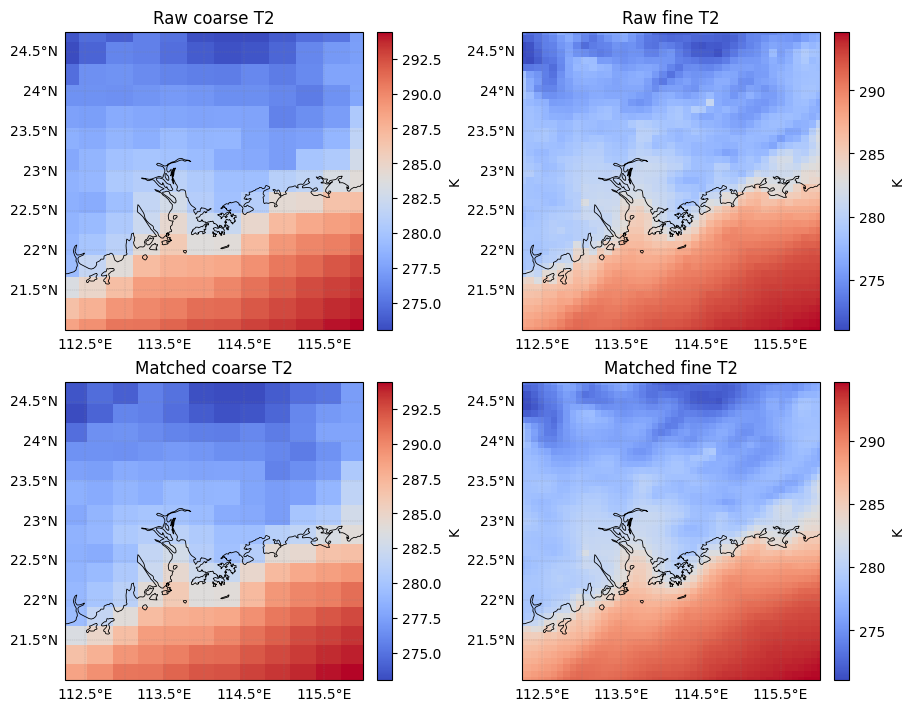

In [4]:
# Plot one variable before and after grid matching.
variable_name = SAMPLE_VARIABLE
variable_index = list(cfg.DL_OUT_SINGLE_LAYER_PARAMS).index(variable_name)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(9, 7),
    constrained_layout=True,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

fields = [
    coarse_raw[TIME_INDEX, variable_index],
    fine_raw[TIME_INDEX, variable_index],
    coarse_matched[TIME_INDEX, variable_index],
    fine_matched[TIME_INDEX, variable_index],
]

titles = [
    "Raw coarse T2",
    "Raw fine T2",
    "Matched coarse T2",
    "Matched fine T2",
]

for i in range(4):
    ax = axes.flat[i]
    image, label = plot_weather_map(ax, fields[i], variable_name, titles[i], colorbar_label="K")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label=label)

display(fig)
plt.close(fig)


## Part 2: Data Transformation

Precipitation has many zeros and a few large values. This makes it hard for the model to learn directly.

The dataset changes accumulated precipitation into:

`log(precipitation + 0.001)`

The small number avoids taking `log(0)`.


In [5]:
coarse_npz_path = f"{cfg.DATA_DIR}/wrf_npz_coarse/wrf_{SAMPLE_YEAR}_coarse.npz"

with np.load(coarse_npz_path, allow_pickle=False) as coarse_npz:
    raw_precip = coarse_npz["ACC_6H_PRECIP"][TIME_INDEX]

    # Negative precipitation is not physical, so clip it to zero first.
    raw_precip = np.maximum(raw_precip, 0.0)

    # This helper applies the same transform used by the dataset.
    log_precip = read_weather_channel(coarse_npz, "LN_ACC_6H_PRECIP")[TIME_INDEX]

print("One precipitation grid cell")
print("raw precip:         ", raw_precip[0, 0])
print("log(precip + 0.001):", log_precip[0, 0])


One precipitation grid cell
raw precip:          0.0020486259483831763
log(precip + 0.001): -5.793064


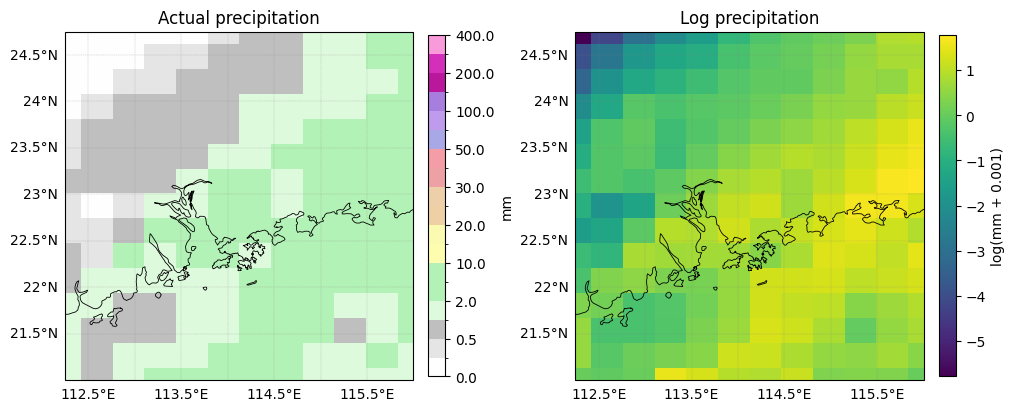

In [6]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    constrained_layout=True,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

image, label = plot_weather_map(
    axes[0],
    raw_precip,
    "LN_ACC_6H_PRECIP",
    "Actual precipitation",
    colorbar_label="mm",
    precip_is_log=False,
)
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04, label=label)

image, label = plot_weather_map(
    axes[1],
    log_precip,
    "LOG_PRECIP",
    "Log precipitation",
    colorbar_label="log(mm + 0.001)",
)
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04, label=label)

display(fig)
plt.close(fig)


## Part 3: Residual Target Construction

The model does not predict the whole fine field directly.

Instead, the target is:

`residual = fine field - matched coarse field`

Later, prediction is reconstructed with:

`predicted fine field = matched coarse field + predicted residual`


In [7]:
# Build residuals for every time, variable, row, and column.
residual = fine_matched - coarse_matched

row = cfg.HIGH_RES_SHP[0] // 2
col = cfg.HIGH_RES_SHP[1] // 2

coarse_value = coarse_matched[TIME_INDEX, variable_index, row, col]
fine_value = fine_matched[TIME_INDEX, variable_index, row, col]
residual_value = residual[TIME_INDEX, variable_index, row, col]
reconstructed_value = coarse_value + residual_value

print("Center grid-cell example for", variable_name)
print("coarse value:       ", round(float(coarse_value), 3))
print("fine value:         ", round(float(fine_value), 3))
print("residual value:     ", round(float(residual_value), 3))
print("coarse + residual:  ", round(float(reconstructed_value), 3))


Center grid-cell example for T2
coarse value:        279.56
fine value:          278.975
residual value:      -0.585
coarse + residual:   278.975


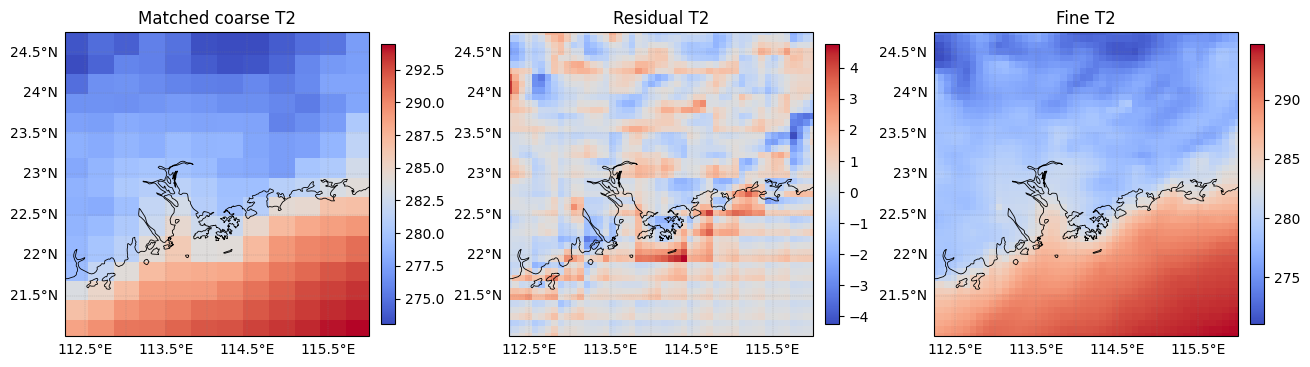

In [8]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(13, 4),
    constrained_layout=True,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

plot_fields = [
    coarse_matched[TIME_INDEX, variable_index],
    residual[TIME_INDEX, variable_index],
    fine_matched[TIME_INDEX, variable_index],
]

plot_titles = [
    "Matched coarse T2",
    "Residual T2",
    "Fine T2",
]

for i in range(3):
    image, label = plot_weather_map(axes[i], plot_fields[i], variable_name, plot_titles[i])
    fig.colorbar(image, ax=axes[i], fraction=0.046, pad=0.04, label=label)

display(fig)
plt.close(fig)


## Part 4: Data Normalization

Weather variables have different units and sizes. For example, pressure values are much larger than wind values.

Normalization changes each channel with:

`normalized value = (value - mean) / standard deviation`

Inputs use raw-weather statistics. Targets use residual statistics.


In [9]:
raw_mean, raw_std = load_channel_stats(cfg.RAW_STATS, cfg.DL_OUT_SINGLE_LAYER_PARAMS)
residual_mean, residual_std = load_channel_stats(
    cfg.RESIDUAL_STATS,
    cfg.DL_OUT_SINGLE_LAYER_PARAMS,
)

input_normalizer = channel_normalizer(raw_mean, raw_std)
residual_normalizer = channel_normalizer(residual_mean, residual_std)

coarse_one = coarse_matched[TIME_INDEX]
residual_one = residual[TIME_INDEX]

coarse_norm_one = input_normalizer(coarse_one)
residual_norm_one = residual_normalizer(residual_one)

print("One center grid-cell example for", variable_name)
print("physical coarse value:       ", round(float(coarse_one[variable_index, row, col]), 3))
print("normalized coarse value:     ", round(float(coarse_norm_one[variable_index, row, col]), 3))
print("physical residual value:     ", round(float(residual_one[variable_index, row, col]), 3))
print("normalized residual value:   ", round(float(residual_norm_one[variable_index, row, col]), 3))


One center grid-cell example for T2
physical coarse value:        279.56
normalized coarse value:      -2.109
physical residual value:      -0.585
normalized residual value:    -0.909


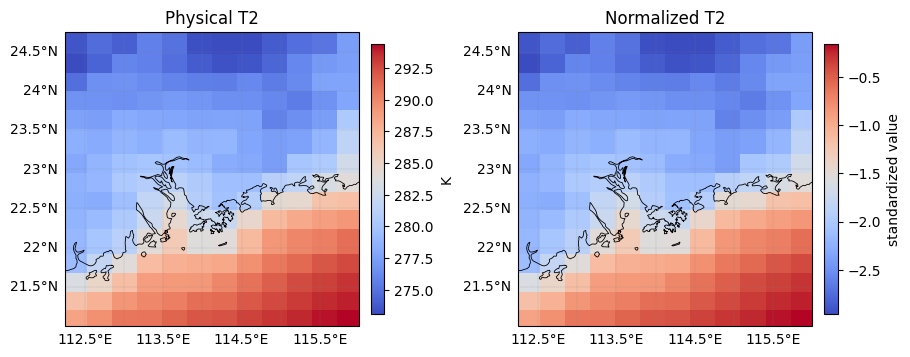

In [10]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4),
    constrained_layout=True,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

image, label = plot_weather_map(
    axes[0],
    coarse_one[variable_index],
    variable_name,
    "Physical T2",
    colorbar_label="K",
)
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04, label=label)

image, label = plot_weather_map(
    axes[1],
    coarse_norm_one[variable_index],
    variable_name,
    "Normalized T2",
    colorbar_label="standardized value",
)
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04, label=label)

display(fig)
plt.close(fig)


## What The Training Notebook Uses

After these four steps, the final model input is:

- normalized matched coarse weather fields
- static channels such as land-sea mask and terrain height
- time features for seasonal and daily cycles

The model target is the normalized residual.
